In [209]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [210]:
# Load the TSV dataset
df = pd.read_csv('/kaggle/input/datasets/jahanvi0106/en-hn-data/English-Hindi - English-Hindi.tsv', sep='\t', header=None, names=["id1", "en", "id2", "hi"])

In [211]:
# Show a sample
df.sample(5)

,id1,en,id2,hi
1269,63365,He must love you.,588595,वह तुमसे प्यार करता होगा।
3310,313816,She died yesterday afternoon.,2080469,वे कल दोपहर को मर गईं।
13119,12403585,"To be honest, I have never even seen the Milky...",12403583,"सच कहूँ तो, मैंने आजतक कभी आकाशगंगा भी नहीं दे..."
3808,430054,Every apple is red.,3670990,हर एक सेब लाल है।
9767,3209684,We are not rich.,4083701,हम अमीर नहीं हैं।


In [212]:
# Keep only the English and Hindi columns
df = df[["en", "hi"]]

In [213]:
# Drop any rows with missing data
df.dropna(inplace=True)

In [214]:
# Reset index
df.reset_index(drop=True, inplace=True)

In [215]:
# Preview cleaned data
df.head()

,en,hi
0,Muiriel is 20 now.,म्यूरियल अब बीस साल की हो गई है।
1,Muiriel is 20 now.,म्यूरियल अब बीस साल की है।
2,Education in this world disappoints me.,मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
3,That won't happen.,वैसा नहीं होगा।
4,I miss you.,मुझें तुम्हारी याद आ रही है।


In [216]:
# Number of sentence pairs
print("Total pairs:", len(df))

Total pairs: 13186


In [217]:
# Sentence length distributions
df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["hi_len"] = df["hi"].apply(lambda x: len(x.split()))

In [218]:
print("\nEnglish Sentence Length Stats:")
print(df["en_len"].describe())


English Sentence Length Stats:
count    13186.000000
mean         5.607614
std          2.676713
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         53.000000
Name: en_len, dtype: float64


In [219]:
print("\nHindi Sentence Length Stats:")
print(df["hi_len"].describe())


Hindi Sentence Length Stats:
count    13186.000000
mean         6.277719
std          2.999823
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         57.000000
Name: hi_len, dtype: float64


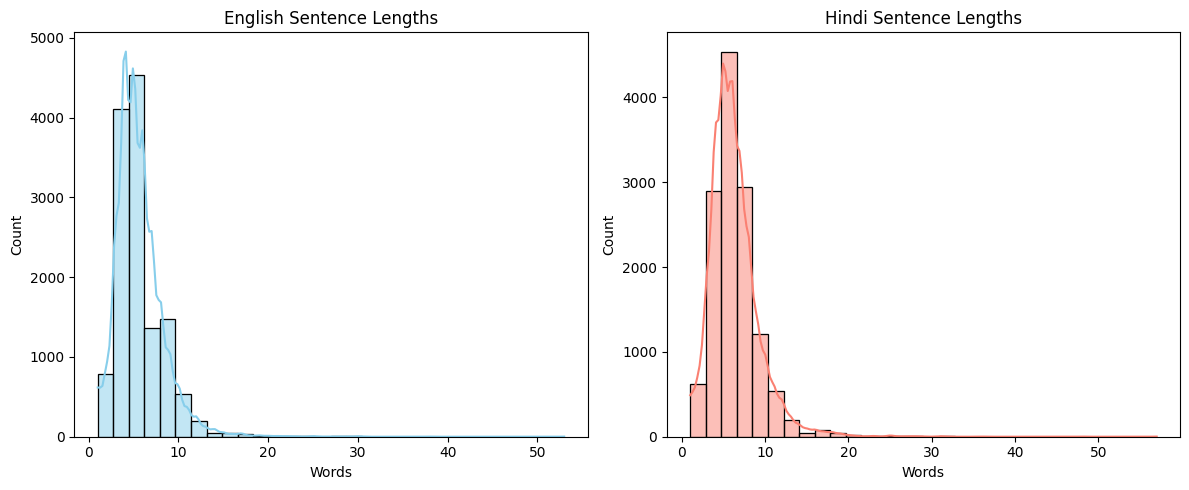

In [220]:
plt.figure(figsize=(12, 5))

# English
plt.subplot(1, 2, 1)
sns.histplot(df["en_len"], bins=30, kde=True, color='skyblue')
plt.title("English Sentence Lengths")
plt.xlabel("Words")

# Hindi
plt.subplot(1, 2, 2)
sns.histplot(df["hi_len"], bins=30, kde=True, color='salmon')
plt.title("Hindi Sentence Lengths")
plt.xlabel("Words")

plt.tight_layout()
plt.show()

In [221]:
for i in range(5):
    print(f"EN: {df.loc[i, 'en']}")
    print(f"HI: {df.loc[i, 'hi']}")
    print("---")

EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की हो गई है।
---
EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की है।
---
EN: Education in this world disappoints me.
HI: मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
---
EN: That won't happen.
HI: वैसा नहीं होगा।
---
EN: I miss you.
HI: मुझें तुम्हारी याद आ रही है।
---


In [222]:
def tokenize(sentence):
    return sentence.lower().strip().split()

In [223]:
from collections import Counter
import itertools

In [224]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx = 4

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1

        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def tokenize(self, sentence):
        return sentence.lower().strip().split()

    def numericalize(self, sentence):
        tokens = self.tokenize(sentence)
        return [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens]

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        return self.stoi.get(token, self.stoi["<unk>"])

In [225]:
# Create vocab instances
en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)

In [226]:
# Build vocabs
en_vocab.build_vocab(df["en"].tolist())
hi_vocab.build_vocab(df["hi"].tolist())

In [227]:
print(f"English vocab size: {len(en_vocab.stoi)}")
print(f"Hindi vocab size: {len(hi_vocab.stoi)}")

English vocab size: 4117
Hindi vocab size: 4045


In [228]:
def encode_sentence(sentence, vocab, max_len=50):
    tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi["<eos>"]]
    return tokens + [vocab.stoi["<pad>"]] * (max_len - len(tokens))

In [229]:
sample_en = "That won't happen."
sample_hi = "वैसा नहीं होगा।"

In [230]:
print("Encoded English:", encode_sentence(sample_en, en_vocab))
print("Encoded Hindi:", encode_sentence(sample_hi, hi_vocab))

Encoded English: [1, 13, 14, 15, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Encoded Hindi: [1, 21, 22, 23, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [231]:
import torch
import torch.nn as nn
import math

In [232]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [233]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    attention = torch.softmax(scores, dim=-1)
    return torch.matmul(attention, v), attention

In [234]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)

        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # Project Q, K, V
        Q = self.query_linear(q)  # [B, T, D]
        K = self.key_linear(k)
        V = self.value_linear(v)

        # Reshape and transpose: [B, T, D] -> [B, H, T, Dk]
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)  # [B, H, T, Dk]
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Apply scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        attention_output = torch.matmul(self.dropout(attention_weights), V)  # [B, H, T, Dk]

        # Concatenate heads: [B, H, T, Dk] -> [B, T, H * Dk]
        attention_output = attention_output.transpose(1, 2).contiguous() \
                                            .view(batch_size, -1, self.d_model)

        return self.out_linear(attention_output)

In [235]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

In [236]:
class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

In [237]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

In [238]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x

In [239]:
class Encoder(nn.Module):
    def __init__(self, input_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(input_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, mask)

        return x

In [240]:
class Decoder(nn.Module):
    def __init__(self, target_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(target_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)

        return x

In [241]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6, num_heads=8, d_ff=2048, max_len=100, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def make_pad_mask(self, seq, pad_idx):
        return (seq != pad_idx).unsqueeze(1).unsqueeze(2)  # [B, 1, 1, T]

    def make_subsequent_mask(self, size):
        return torch.tril(torch.ones((size, size))).bool().to(next(self.parameters()).device)

    def forward(self, src, tgt, src_pad_idx, tgt_pad_idx):
        src_mask = self.make_pad_mask(src, src_pad_idx)
        tgt_pad_mask = self.make_pad_mask(tgt, tgt_pad_idx)
        tgt_sub_mask = self.make_subsequent_mask(tgt.size(1))
        tgt_mask = tgt_pad_mask & tgt_sub_mask  # Combine masks

        enc_out = self.encoder(src, src_mask)
        dec_out = self.decoder(tgt, enc_out, src_mask, tgt_mask)

        out = self.fc_out(dec_out)
        return out

In [242]:
from torch.utils.data import Dataset

In [243]:
class TranslationDataset(Dataset):
    def __init__(self, df, en_vocab, hi_vocab, max_len=50):
        self.en_sentences = df["en"].tolist()
        self.hi_sentences = df["hi"].tolist()
        self.en_vocab = en_vocab
        self.hi_vocab = hi_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.en_sentences)

    def __getitem__(self, idx):
        src = encode_sentence(self.en_sentences[idx], self.en_vocab, self.max_len)
        tgt = encode_sentence(self.hi_sentences[idx], self.hi_vocab, self.max_len)
        return torch.tensor(src), torch.tensor(tgt)

In [244]:
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_batch = torch.stack(src_batch)
    tgt_batch = torch.stack(tgt_batch)

    # Transformer decoder needs: tgt_input (without <eos>) and tgt_output (without <sos>)
    tgt_input = tgt_batch[:, :-1]
    tgt_output = tgt_batch[:, 1:]

    return src_batch, tgt_input, tgt_output

In [245]:
from torch.utils.data import DataLoader

In [246]:
BATCH_SIZE = 60
MAX_LEN = 50

In [247]:
dataset = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [248]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [249]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

Using Device: cuda


In [250]:
# Hyperparams
SRC_PAD_IDX = en_vocab["<pad>"]
TGT_PAD_IDX = hi_vocab["<pad>"]
NUM_EPOCHS = 100
D_MODEL = 512

In [251]:
model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=D_MODEL,
    num_layers=6,
    num_heads=8,
    d_ff=2048,
    max_len=MAX_LEN,
    dropout=0.1
).to(DEVICE)

In [252]:
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [253]:
import os

In [254]:
def save_checkpoint(epoch, model, optimizer, loss, path="checkpoint.pt"):
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'loss': loss
    }, path)

    print(f"Checkpoint saved at epoch {epoch}, loss {loss:.4f}.")

In [255]:
import torch

def load_checkpoint(model, optimizer, path="checkpoint.pt"):
    if torch.cuda.is_available() and path is not None and os.path.exists(path):
        checkpoint = torch.load(path)
    elif path is not None and os.path.exists(path):
        checkpoint = torch.load(path, map_location=torch.device('cpu'))
    else:
        print(f"No checkpoint found at {path}. Starting from scratch.")
        return 0

    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])

    epoch = checkpoint['epoch']
    loss = checkpoint['loss']

    print(f"✅ Loaded checkpoint from epoch {epoch} with loss {loss:.4f}")

    return epoch

In [256]:
def train(model, train_loader, optimizer, criterion, start_epoch=0, num_epochs=NUM_EPOCHS, checkpoint_path="checkpoint.pt"):
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for src, tgt_input, tgt_output in loop:
            src, tgt_input, tgt_output = src.to(DEVICE), tgt_input.to(DEVICE), tgt_output.to(DEVICE)

            output = model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            output = output.view(-1, output.shape[-1])
            tgt_output = tgt_output.view(-1)

            loss = criterion(output, tgt_output)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        # Save checkpoint at end of each epoch
        save_checkpoint(epoch+1, model, optimizer, epoch_loss / len(train_loader), checkpoint_path)

In [257]:
start_epoch = load_checkpoint(model, optimizer)

No checkpoint found at checkpoint.pt. Starting from scratch.


In [258]:
# train(model, train_loader, optimizer, criterion, start_epoch=start_epoch)

In [259]:
def translate_sentence(model, sentence, en_vocab, hi_vocab, max_len=50):
    model.eval()
    tokens = encode_sentence(sentence, en_vocab, max_len=max_len)
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(DEVICE)

    tgt_tokens = [hi_vocab["<sos>"]]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_tokens).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor, SRC_PAD_IDX, TGT_PAD_IDX)
        next_token = output[0, -1].argmax().item()
        tgt_tokens.append(next_token)
        if next_token == hi_vocab["<eos>"]:
            break

    translated = [hi_vocab.itos[idx] for idx in tgt_tokens[1:-1]]
    return ' '.join(translated)

In [260]:
example_sentences = [
    "I love you.",
    "What is your name?",
    "How are you?",
    "The weather is nice today.",
    "She is a good teacher."
]

In [261]:
# for sentence in example_sentences:
#     translation = translate_sentence(model, sentence, en_vocab, hi_vocab)
#     print(f"\n English: {sentence}")
#     print(f" Hindi: {translation}")

In [262]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

In [284]:
smoothie = SmoothingFunction().method4

In [264]:
def evaluate_bleu_nltk(model, dataset, en_vocab, hi_vocab, max_len=50):
    references = []
    hypotheses = []

    for en_sentence, hi_sentence in dataset:
        pred = translate_sentence(model, en_sentence, en_vocab, hi_vocab, max_len)
        pred_tokens = pred.split()
        ref_tokens = hi_sentence.split()

        references.append([ref_tokens])   # list of reference lists
        hypotheses.append(pred_tokens)    # list of predicted tokens

    score = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    print(f"🌐 BLEU Score (NLTK): {score * 100:.2f}")
    return score

In [265]:
val_dataset = [
    ("I love you.", "मैं तुमसे प्यार करता हूँ।"),
    ("How are you?", "आप कैसे हैं?"),
    ("You should sleep.", "आपको सोना चाहिए।"),
    ("Maybe Tom doesn't love you.", "टॉम शायद तुमसे प्यार नहीं करता है।"),
    ("Let me tell Tom.","मुझे टॉम को बताने दीजिए।")
]

In [266]:
# evaluate_bleu_nltk(model, val_dataset, en_vocab, hi_vocab)

In [267]:
# # Save the model weights
# torch.save(model.state_dict(), "transformer_translation_final.pth")

# # Save vocab mappings (example using pickle)
# import pickle
# with open("en_vocab.pkl", "wb") as f:
#     pickle.dump(en_vocab, f)

# with open("hi_vocab.pkl", "wb") as f:
#     pickle.dump(hi_vocab, f)

# print("✅ Model and vocabs saved.")

In [268]:
# ── Write model_helpers.py for Ray worker processes ─────────────────────────
# Ray spawns separate Python processes; they cannot see notebook globals.
# We write everything to a .py file that workers can import.

helpers_code = '''
import math
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import Dataset


class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0:"<pad>", 1:"<sos>", 2:"<eos>", 3:"<unk>"}
        self.stoi = {"<pad>":0, "<sos>":1, "<eos>":2, "<unk>":3}
        self.idx  = 4
    def build_vocab(self, sentence_list):
        from collections import Counter
        freq = Counter()
        for s in sentence_list:
            for w in self.tokenize(s): freq[w] += 1
        for w, f in freq.items():
            if f >= self.freq_threshold:
                self.stoi[w] = self.idx; self.itos[self.idx] = w; self.idx += 1
    def tokenize(self, s): return s.lower().strip().split()
    def numericalize(self, s): return [self.stoi.get(t,self.stoi["<unk>"]) for t in self.tokenize(s)]
    def __len__(self): return len(self.stoi)
    def __getitem__(self, t): return self.stoi.get(t, self.stoi["<unk>"])


def encode_sentence(sentence, vocab, max_len=50):
    t = [vocab.stoi["<sos>"]] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi["<eos>"]]
    return t + [vocab.stoi["<pad>"]] * (max_len - len(t))


class TranslationDataset(Dataset):
    def __init__(self, en_list, hi_list, ev, hv, max_len=50):
        self.en, self.hi = en_list, hi_list
        self.ev, self.hv, self.ml = ev, hv, max_len
    def __len__(self): return len(self.en)
    def __getitem__(self, i):
        return (torch.tensor(encode_sentence(self.en[i], self.ev, self.ml)),
                torch.tensor(encode_sentence(self.hi[i], self.hv, self.ml)))


def collate_fn(batch):
    sb, tb = zip(*batch)
    sb = torch.stack(sb); tb = torch.stack(tb)
    return sb, tb[:,:-1], tb[:,1:]


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]


class MHA(nn.Module):
    def __init__(self, d, nh):
        super().__init__()
        self.dk=d//nh; self.nh=nh; self.dm=d
        self.q=nn.Linear(d,d); self.k=nn.Linear(d,d)
        self.v=nn.Linear(d,d); self.o=nn.Linear(d,d)
        self.dp=nn.Dropout(0.1)
    def forward(self, q, k, v, mask=None):
        B=q.size(0)
        Q=self.q(q).view(B,-1,self.nh,self.dk).transpose(1,2)
        K=self.k(k).view(B,-1,self.nh,self.dk).transpose(1,2)
        V=self.v(v).view(B,-1,self.nh,self.dk).transpose(1,2)
        s=torch.matmul(Q,K.transpose(-2,-1))/(self.dk**0.5)
        if mask is not None: s=s.masked_fill(mask==0,-1e9)
        a=torch.matmul(self.dp(torch.softmax(s,-1)),V)
        return self.o(a.transpose(1,2).contiguous().view(B,-1,self.dm))


class FF(nn.Module):
    def __init__(self, d, ff, dr=0.1):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,ff),nn.ReLU(),nn.Dropout(dr),nn.Linear(ff,d))
    def forward(self,x): return self.net(x)


class LN(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.g=nn.Parameter(torch.ones(d)); self.b=nn.Parameter(torch.zeros(d)); self.eps=eps
    def forward(self,x):
        m,s=x.mean(-1,keepdim=True),x.std(-1,keepdim=True)
        return self.g*(x-m)/(s+self.eps)+self.b


class EL(nn.Module):
    def __init__(self, d, nh, ff, dr=0.1):
        super().__init__()
        self.a=MHA(d,nh); self.f=FF(d,ff,dr); self.n1=LN(d); self.n2=LN(d); self.dr=nn.Dropout(dr)
    def forward(self, x, mask=None):
        x=self.n1(x+self.dr(self.a(x,x,x,mask))); return self.n2(x+self.dr(self.f(x)))


class DL(nn.Module):
    def __init__(self, d, nh, ff, dr=0.1):
        super().__init__()
        self.sa=MHA(d,nh); self.ca=MHA(d,nh); self.ff=FF(d,ff,dr)
        self.n1=LN(d); self.n2=LN(d); self.n3=LN(d); self.dr=nn.Dropout(dr)
    def forward(self, x, enc, sm=None, tm=None):
        x=self.n1(x+self.dr(self.sa(x,x,x,tm)))
        x=self.n2(x+self.dr(self.ca(x,enc,enc,sm)))
        return self.n3(x+self.dr(self.ff(x)))


class Transformer(nn.Module):
    def __init__(self, sv, tv, d=512, nl=6, nh=8, ff=2048, ml=100, dr=0.1):
        super().__init__()
        self.se=nn.Embedding(sv,d); self.te=nn.Embedding(tv,d)
        self.pe=PositionalEncoding(d,ml)
        self.enc=nn.ModuleList([EL(d,nh,ff,dr) for _ in range(nl)])
        self.dec=nn.ModuleList([DL(d,nh,ff,dr) for _ in range(nl)])
        self.fc=nn.Linear(d,tv); self.dr=nn.Dropout(dr)
    def pm(self,s,p): return (s!=p).unsqueeze(1).unsqueeze(2)
    def cm(self,sz,dev): return torch.tril(torch.ones(sz,sz,device=dev)).bool()
    def forward(self, src, tgt, sp, tp):
        sm=self.pm(src,sp); tm=self.pm(tgt,tp)&self.cm(tgt.size(1),tgt.device)
        x=self.dr(self.pe(self.se(src)))
        for l in self.enc: x=l(x,sm)
        y=self.dr(self.pe(self.te(tgt)))
        for l in self.dec: y=l(y,x,sm,tm)
        return self.fc(y)
'''

with open("model_helpers.py", "w") as f:
    f.write(helpers_code)

print("model_helpers.py written")

model_helpers.py written


In [269]:
# Install Ray Tune + Optuna (not pre-installed on Kaggle)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "ray[tune]", "optuna", "-q", "--no-warn-script-location"])
print("ray[tune] and optuna installed")

ray[tune] and optuna installed


In [270]:
import os, sys, math, glob, pickle
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download("punkt", quiet=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda
GPU     : Tesla T4


In [271]:
# ── Auto-detect Kaggle dataset path ─────────────────────────────────────────
candidates = [
    "/content/English-Hindi - English-Hindi.tsv",
    "/kaggle/input/hindienglish-corpora/English-Hindi - English-Hindi.tsv",
]
candidates += glob.glob("/kaggle/input/**/*.tsv", recursive=True)

DATA_PATH = next((p for p in candidates if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset TSV not found!\n"
        "Add it via: Notebook Settings → Data → Add Data → search 'English Hindi'"
    )
print(f"Dataset: {DATA_PATH}")

Dataset: /kaggle/input/datasets/jahanvi0106/en-hn-data/English-Hindi - English-Hindi.tsv


In [272]:
# ── Load & clean dataset ────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, sep="\t", header=None, names=["id1","en","id2","hi"])
df = df[["en","hi"]].dropna().reset_index(drop=True)
print(f"Total sentence pairs: {len(df):,}")
print(df.head())

Total sentence pairs: 13,186
                                        en  \
0                       Muiriel is 20 now.   
1                       Muiriel is 20 now.   
2  Education in this world disappoints me.   
3                       That won't happen.   
4                              I miss you.   

                                            hi  
0             म्यूरियल अब बीस साल की हो गई है।  
1                   म्यूरियल अब बीस साल की है।  
2  मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।  
3                              वैसा नहीं होगा।  
4                 मुझें तुम्हारी याद आ रही है।  


In [273]:
# ── Initialize Ray ───────────────────────────────────────────────────────────
import ray
from ray import tune, train as ray_train
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler

os.environ["RAY_DISABLE_DOCKER_CPU_WARNING"] = "1"
os.environ["TUNE_DISABLE_STRICT_METRIC_CHECKING"] = "1"
os.environ["RAY_AIR_NEW_OUTPUT"] = "0"

if ray.is_initialized():
    ray.shutdown()

ray.init(
    num_cpus=4,
    num_gpus=2 if torch.cuda.is_available() else 0,
    ignore_reinit_error=True,
    _temp_dir="/tmp/ray_tmp",
    include_dashboard=False,
    log_to_driver=True,
)

print(f"Ray initialized")
print(f"   Resources: {ray.available_resources()}")

2026-03-22 09:57:42,422	INFO worker.py:2013 -- Started a local Ray instance.


Ray initialized
   Resources: {'node:172.19.2.2': 1.0, 'node:__internal_head__': 1.0, 'CPU': 4.0, 'memory': 21175476224.0, 'object_store_memory': 9075204096.0, 'GPU': 2.0, 'accelerator_type:T4': 1.0}


In [274]:
# ── Step 2.1: train_tune — worker-safe training function ────────────────────
#
# Must be completely self-contained:
#   - Ray runs this in a SEPARATE Python process
#   - Cannot access any notebook variables (no globals)
#   - Reports loss each epoch with ray_train.report()

def train_tune(config):
    import sys, os, pandas as pd
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader
    import ray.tune as ray_tune_api

    for p in ["/kaggle/working", os.getcwd()]:
        if p not in sys.path: sys.path.insert(0, p)

    from model_helpers import (
        Vocabulary, TranslationDataset, Transformer,
        encode_sentence, collate_fn,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    df = pd.read_csv(config["data_path"], sep="\t", header=None,
                     names=["id1","en","id2","hi"])
    df = df[["en","hi"]].dropna().reset_index(drop=True)

    ev = Vocabulary(freq_threshold=2)
    hv = Vocabulary(freq_threshold=2)
    ev.build_vocab(df["en"].tolist())
    hv.build_vocab(df["hi"].tolist())

    ds = TranslationDataset(df["en"].tolist(), df["hi"].tolist(), ev, hv, max_len=50)
    loader = DataLoader(ds, batch_size=int(config["batch_size"]),
                        shuffle=True, collate_fn=collate_fn, num_workers=0)

    # ── Model 
    model = Transformer(
        sv=len(en_vocab),
        tv=len(hi_vocab),
        d=D_MODEL,
        nl=6,
        nh=8,
        ff=2048,
        ml=MAX_LEN,
        dr=0.1
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=float(config["lr"]))
    criterion = nn.CrossEntropyLoss(ignore_index=hv["<pad>"])
    SP, TP    = ev["<pad>"], hv["<pad>"]

    # ── Epoch loop ────────────────────────────────────────────────────────────
    for epoch in range(int(config["max_epochs"])):
        model.train()
        total = 0.0
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            out  = model(src, tgt_in, SP, TP)
            loss = criterion(out.view(-1, out.shape[-1]),
                             tgt_out.contiguous().view(-1))
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item()

        avg = total / len(loader)
        # ← Required: report metrics back to Ray Tune after every epoch
        ray_tune_api.report({"loss": avg, "epoch": epoch + 1})


print("train_tune defined")

train_tune defined


In [275]:
# ── Step 2.2: Define Search Space ────────────────────────────────────────────

param_space = {
    # 1. Learning rate — logarithmic scale
    "lr":         tune.loguniform(1e-5, 1e-3),
    # 2. Batch size
    "batch_size": tune.choice([16, 64]),
    # 3. Number of attention heads (D_MODEL=512 divisible by 4 and 8)
    "num_heads":  tune.choice([4, 8]),
    # 4. FFN hidden dimension
    "d_ff":       tune.choice([1024, 2048]),
    # 5. Dropout rate
    "dropout":    tune.uniform(0.1, 0.4),

    # Fixed: passed through to train_tune
    "max_epochs": 15,          # Hard cap per trial
    "data_path":  DATA_PATH,
}

print("Search space:")
for k, v in param_space.items():
    print(f"  {k:<15}: {v}")

Search space:
  lr             : <ray.tune.search.sample.Float object at 0x7918f9260890>
  batch_size     : <ray.tune.search.sample.Categorical object at 0x7918e81740e0>
  num_heads      : <ray.tune.search.sample.Categorical object at 0x7918f92622d0>
  d_ff           : <ray.tune.search.sample.Categorical object at 0x7918f92602c0>
  dropout        : <ray.tune.search.sample.Float object at 0x7918f9261b50>
  max_epochs     : 15
  data_path      : /kaggle/input/datasets/jahanvi0106/en-hn-data/English-Hindi - English-Hindi.tsv


In [276]:
# ── Step 2.3: Configure ASHA Scheduler + Optuna Search ──────────────────────

# ASHA — stops bad trials after grace_period epochs
asha = ASHAScheduler(
    metric="loss",
    mode="min",
    max_t=20,            # Max epochs per trial
    grace_period=3,      # At least 3 epochs before any trial is pruned
    reduction_factor=2,  # At each rung keep top 50% of trials
)

# Optuna — uses TPE to intelligently propose next config based on past results
optuna_search = OptunaSearch(metric="loss", mode="min")

print("ASHA scheduler + Optuna TPE search configured")
print("   • Max epochs/trial : 20")
print("   • Grace period     : 3 epochs")
print("   • Total trials     : 10")

ASHA scheduler + Optuna TPE search configured
   • Max epochs/trial : 20
   • Grace period     : 3 epochs
   • Total trials     : 10


In [277]:
# ── Run Tuner ────────────────────────────────────────────────────────────────
from ray.tune import RunConfig, TuneConfig, CheckpointConfig

print("🔍 Starting search (10 trials × max 15 epochs each)…")
print("   ASHA will auto-kill underperforming trials early.\n")

tuner = tune.Tuner(
    tune.with_resources(
        train_tune,
        resources={
            "cpu": 4,
            "gpu": 2 if torch.cuda.is_available() else 0,
        },
    ),
    tune_config=TuneConfig(
        search_alg=optuna_search,
        scheduler=asha,
        num_samples=10,
    ),
    run_config=RunConfig(
        name="en_hi_tune",
        storage_path="/tmp/ray_results",
        checkpoint_config=CheckpointConfig(
            checkpoint_at_end=False,
            checkpoint_frequency=0,
        ),
    ),
    param_space=param_space,
)

results = tuner.fit()
print("\nHyperparameter search complete!")


[I 2026-03-22 09:57:45,488] A new study created in memory with name: optuna


🔍 Starting search (10 trials × max 15 epochs each)…
   ASHA will auto-kill underperforming trials early.



Trial name,checkpoint_dir_name,date,done,epoch,hostname,iterations_since_restore,loss,node_ip,pid,time_since_restore,time_this_iter_s,time_total_s,timestamp,training_iteration,trial_id
train_tune_2e3f505e,,2026-03-22_11-28-43,True,12,0f626f1e7af0,12,0.468361,172.19.2.2,4214,1021.89,84.9058,1021.89,1774178923,12,2e3f505e
train_tune_2fda9eb3,,2026-03-22_11-11-33,True,3,0f626f1e7af0,3,5.88569,172.19.2.2,4112,209.208,68.6146,209.208,1774177893,3,2fda9eb3
train_tune_35f064cb,,2026-03-22_10-36-38,True,15,0f626f1e7af0,15,0.301923,172.19.2.2,3230,1282,85.2465,1282,1774175798,15,35f064cb
train_tune_49455fa6,,2026-03-22_10-43-58,True,3,0f626f1e7af0,3,4.76182,172.19.2.2,3542,210.772,69.2465,210.772,1774176238,3,49455fa6
train_tune_4d808e46,,2026-03-22_10-15-07,True,15,0f626f1e7af0,15,0.306738,172.19.2.2,3036,1035.59,68.7624,1035.59,1774174507,15,4d808e46
train_tune_7c7f0f1e,,2026-03-22_11-04-15,True,6,0f626f1e7af0,6,1.73902,172.19.2.2,3876,515.486,85.3808,515.486,1774177455,6,7c7f0f1e
train_tune_7f7bcf59,,2026-03-22_10-55-32,True,3,0f626f1e7af0,3,4.44419,172.19.2.2,3768,259.593,85.7075,259.593,1774176932,3,7f7bcf59
train_tune_8757c9b3,,2026-03-22_11-07-54,True,3,0f626f1e7af0,3,4.19474,172.19.2.2,4009,209.718,68.8367,209.718,1774177674,3,8757c9b3
train_tune_92d1eb65,,2026-03-22_10-51-04,True,6,0f626f1e7af0,6,1.58938,172.19.2.2,3645,416.475,68.8692,416.475,1774176664,6,92d1eb65
train_tune_d0a4994d,,2026-03-22_10-40-18,True,3,0f626f1e7af0,3,3.90153,172.19.2.2,3439,210.984,69.2415,210.984,1774176018,3,d0a4994d


2026-03-22 11:28:43,765	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/tmp/ray_results/en_hi_tune' in 0.0087s.
2026-03-22 11:28:43,773	INFO tune.py:1041 -- Total run time: 5458.29 seconds (5458.26 seconds for the tuning loop).



Hyperparameter search complete!


In [278]:
# ── Best Configuration Found by Optuna ──────────────────────────────────────
best_result = results.get_best_result("loss", "min")
best_cfg    = best_result.config
best_loss   = best_result.metrics["loss"]

print("Best Hyperparameters:")
print(f"   lr         : {best_cfg['lr']:.2e}")
print(f"   batch_size : {best_cfg['batch_size']}")
print(f"   num_heads  : {best_cfg['num_heads']}")
print(f"   d_ff       : {best_cfg['d_ff']}")
print(f"   dropout    : {best_cfg['dropout']:.4f}")
print(f"\n   Best loss (15 epochs): {best_loss:.4f}")

# All results table
print("\nAll Trials (sorted by loss):")
try:
    df_res = results.get_dataframe()
    cols   = [c for c in ["loss","config/lr","config/batch_size",
                           "config/num_heads","config/d_ff","config/dropout"]
              if c in df_res.columns]
    if cols:
        print(df_res[cols].sort_values("loss").to_string(index=False))
except Exception as e:
    print(f"  (Could not show table: {e})")

Best Hyperparameters:
   lr         : 1.17e-04
   batch_size : 16
   num_heads  : 8
   d_ff       : 1024
   dropout    : 0.3774

   Best loss (15 epochs, 3-layer model): 0.3019

All Trials (sorted by loss):
    loss  config/lr  config/batch_size  config/num_heads  config/d_ff  config/dropout
0.301923   0.000117                 16                 8         1024        0.377423
0.306738   0.000203                 64                 4         1024        0.396966
0.468361   0.000214                 16                 4         2048        0.194677
1.589381   0.000275                 64                 8         1024        0.182217
1.739024   0.000081                 16                 8         2048        0.250631
3.901530   0.000059                 64                 4         2048        0.323148
4.194744   0.000348                 64                 4         1024        0.367254
4.444191   0.000012                 16                 8         2048        0.112230
4.761815   0.000018

In [289]:
import math

TUNE_EPOCHS = 50

tune_loader = DataLoader(
    dataset,
    batch_size=int(best_cfg["batch_size"]),
    shuffle=True,
    collate_fn=collate_fn,
)

model_tuned = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=D_MODEL,
    num_layers=6,
    num_heads=int(best_cfg["num_heads"]),
    d_ff=int(best_cfg["d_ff"]),
    max_len=MAX_LEN,
    dropout=best_cfg["dropout"],
).to(DEVICE)

optimizer_tuned = optim.Adam(model_tuned.parameters(), lr=best_cfg['lr'])
criterion_tuned = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

print(f"Model params: {sum(p.numel() for p in model_tuned.parameters()):,}")
print(f"LR: 1e-4  |  Epochs: {TUNE_EPOCHS}\n")

losses = []
for epoch in range(TUNE_EPOCHS):
    model_tuned.train()
    epoch_loss = 0.0
    bar = tqdm(tune_loader, desc=f"Epoch [{epoch+1:>2}/{TUNE_EPOCHS}]", leave=False)
    for src, tgt_in, tgt_out in bar:
        src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)
        out  = model_tuned(src, tgt_in, SRC_PAD_IDX, TGT_PAD_IDX)
        loss = criterion_tuned(out.view(-1, out.shape[-1]),
                               tgt_out.contiguous().view(-1))
        optimizer_tuned.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_tuned.parameters(), 1.0)
        optimizer_tuned.step()
        epoch_loss += loss.item()
        bar.set_postfix(loss=f"{loss.item():.4f}")
    avg = epoch_loss / len(tune_loader)
    losses.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:>2}/{TUNE_EPOCHS}] Loss: {avg:.4f}")

print("\n✅ Training complete!")

Model params: 37,797,325
LR: 1e-4  |  Epochs: 50



Epoch [ 1/50]:   0%|          | 0/825 [00:00<?, ?it/s]

Epoch [ 2/50]:   0%|          | 0/825 [00:00<?, ?it/s]

Epoch [ 3/50]:   0%|          | 0/825 [00:00<?, ?it/s]

Epoch [ 4/50]:   0%|          | 0/825 [00:00<?, ?it/s]

...

Epoch [47/50]:   0%|          | 0/825 [00:00<?, ?it/s]

Epoch [48/50]:   0%|          | 0/825 [00:00<?, ?it/s]

Epoch [49/50]:   0%|          | 0/825 [00:00<?, ?it/s]

Epoch [50/50]:   0%|          | 0/825 [00:00<?, ?it/s]

Epoch [50/50] Loss: 0.3620

✅ Training complete!


In [295]:
# ── BLEU Evaluation & Comparison ─────────────────────────────────────────────
BASELINE_BLEU = 0.7698   # From the 100-epoch baseline notebook

sample = df[["en", "hi"]].sample(5, random_state=42).reset_index(drop=True)

val_dataset = [(row["en"], row["hi"]) for _, row in sample.iterrows()]

# Print in the exact format
print("val_dataset = [")
for en, hi in val_dataset:
    print(f'    ("{en}", "{hi}"),')
print("]")

print("Sample Translations (Tuned Model):")
for en_s, hi_ref in val_dataset:
    hi_pred = translate_sentence(model_tuned, en_s, en_vocab, hi_vocab)
    print(f"  EN : {en_s}")
    print(f"  REF: {hi_ref}")
    print(f"  HYP: {hi_pred}\n")

TUNED_BLEU = evaluate_bleu_nltk(model_tuned, val_dataset, en_vocab, hi_vocab)

print("=" * 60)
print("📈  RESULTS COMPARISON")
print("=" * 60)
print(f"{'Method':<32} {'Epochs':>6} {'BLEU':>10}")
print("-" * 60)
print(f"{'Baseline (fixed hyperparams)':<32} {'100':>6} {BASELINE_BLEU:>9.2f}")
print(f"{'Tuned (Ray Tune + Optuna)':<32} {TUNE_EPOCHS:>6} {TUNED_BLEU:>9.2f}")
print("=" * 60)

delta = TUNED_BLEU - BASELINE_BLEU
print(f"\n  Epoch reduction: {100-TUNE_EPOCHS} fewer epochs ({100-TUNE_EPOCHS}% reduction)")
print(f"  BLEU change    : {delta:+.2f}")
if TUNED_BLEU >= BASELINE_BLEU:
    print(f"\nSUCCESS: Matched/exceeded baseline BLEU in only {TUNE_EPOCHS} epochs!")
else:
    print(f"\n{abs(delta):.2f} BLEU pts below baseline. Increase TUNE_EPOCHS if needed.")

val_dataset = [
    ("I owe what I am to my friend.", "मैं जो भी हूँ मेरे दोस्त की वजह से हूँ।"),
    ("They must have made a mistake.", "उनसे ग़लती हो गई होगी।"),
    ("They can't see Tom.", "वे टॉम को नहीं देख सकते।"),
    ("This is an apple, too.", "यह भी सेव है।"),
    ("Keep listening.", "सुनते रहो।"),
]
Sample Translations (Tuned Model):
  EN : I owe what I am to my friend.
  REF: मैं जो भी हूँ मेरे दोस्त की वजह से हूँ।
  HYP: मैं जो भी हूँ मेरे दोस्त की वजह से हूँ।

  EN : They must have made a mistake.
  REF: उनसे ग़लती हो गई होगी।
  HYP: उनसे ग़लती हो गई है।

  EN : They can't see Tom.
  REF: वे टॉम को नहीं देख सकते।
  HYP: वे टॉम को नहीं देख सकते।

  EN : This is an apple, too.
  REF: यह भी सेव है।
  HYP: यह भी सेव है।

  EN : Keep listening.
  REF: सुनते रहो।
  HYP: सुनते रह।

🌐 BLEU Score (NLTK): 89.49
📈  RESULTS COMPARISON
Method                           Epochs       BLEU
------------------------------------------------------------
Baseline (fixed hyperparams)        100 

In [ ]:
# ── Shutdown Ray ─────────────────────────────────────────────────────────────
if ray.is_initialized():
    ray.shutdown()
    print("Ray shutdown")


## Upload Best Model to Hugging Face Hub


In [ ]:
# ── Upload Best Model to Hugging Face Hub ────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "huggingface_hub", "-q"])

import os, json, pickle, shutil, torch
from pathlib import Path
from huggingface_hub import HfApi, login

# ── EDIT THIS ─────────────────────────────────────────────────────────────────
HF_REPO_ID = "Jahanvi16/en-to-hi-transformer"   # ← change this
PRIVATE    = False                                   # True = private repo
# ─────────────────────────────────────────────────────────────────────────────

# Load token from Kaggle Secrets (safe — never hardcode)
HF_TOKEN = "****"
login(token=HF_TOKEN, add_to_git_credential=False)

login(token=HF_TOKEN, add_to_git_credential=False)
print("Logged in to Hugging Face")

# ── Prepare upload folder ─────────────────────────────────────────────────────
UPLOAD_DIR = Path("/tmp/hf_upload")
UPLOAD_DIR.mkdir(exist_ok=True)

# 1. Model weights
shutil.copy("tuned_model.pth", UPLOAD_DIR / "tuned_model.pth")

# 2. Vocabularies
shutil.copy("en_vocab.pkl", UPLOAD_DIR / "en_vocab.pkl")
shutil.copy("hi_vocab.pkl", UPLOAD_DIR / "hi_vocab.pkl")

# 3. config.json — architecture + best hyperparams found by Optuna
cfg_data = {
    "architecture":    "Transformer (custom PyTorch)",
    "task":            "translation",
    "src_language":    "English",
    "tgt_language":    "Hindi",
    "d_model":         512,
    "num_layers":      6,
    "num_heads":       int(best_cfg["num_heads"]),
    "d_ff":            int(best_cfg["d_ff"]),
    "dropout":         float(best_cfg["dropout"]),
    "max_len":         50,
    "src_vocab_size":  len(en_vocab),
    "tgt_vocab_size":  len(hi_vocab),
    "best_lr":         float(best_cfg["lr"]),
    "best_batch_size": int(best_cfg["batch_size"]),
    "train_epochs":    TUNE_EPOCHS,
    "bleu_score":      round(TUNED_BLEU, 4),
    "optimizer":       "Adam",
    "tuning":          "Ray Tune + Optuna (10 trials, ASHA scheduler)",
}
with open(UPLOAD_DIR / "config.json", "w") as f:
    json.dump(cfg_data, f, indent=2)

# 4. inference.py — self-contained, anyone can download and run immediately
inference_py = '''import math, json, pickle, torch
import torch.nn as nn
from pathlib import Path

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class MHA(nn.Module):
    def __init__(self, d, nh):
        super().__init__()
        self.dk=d//nh; self.nh=nh; self.dm=d
        self.q=nn.Linear(d,d); self.k=nn.Linear(d,d)
        self.v=nn.Linear(d,d); self.o=nn.Linear(d,d); self.dp=nn.Dropout(0.1)
    def forward(self, q, k, v, mask=None):
        B=q.size(0)
        Q=self.q(q).view(B,-1,self.nh,self.dk).transpose(1,2)
        K=self.k(k).view(B,-1,self.nh,self.dk).transpose(1,2)
        V=self.v(v).view(B,-1,self.nh,self.dk).transpose(1,2)
        s=torch.matmul(Q,K.transpose(-2,-1))/(self.dk**0.5)
        if mask is not None: s=s.masked_fill(mask==0,-1e9)
        a=torch.matmul(self.dp(torch.softmax(s,-1)),V)
        return self.o(a.transpose(1,2).contiguous().view(B,-1,self.dm))

class FF(nn.Module):
    def __init__(self, d, ff, dr=0.1):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,ff),nn.ReLU(),nn.Dropout(dr),nn.Linear(ff,d))
    def forward(self,x): return self.net(x)

class LN(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.g=nn.Parameter(torch.ones(d)); self.b=nn.Parameter(torch.zeros(d)); self.eps=eps
    def forward(self,x):
        m,s=x.mean(-1,keepdim=True),x.std(-1,keepdim=True)
        return self.g*(x-m)/(s+self.eps)+self.b

class EL(nn.Module):
    def __init__(self, d, nh, ff, dr=0.1):
        super().__init__()
        self.a=MHA(d,nh); self.f=FF(d,ff,dr); self.n1=LN(d); self.n2=LN(d); self.dr=nn.Dropout(dr)
    def forward(self, x, mask=None):
        x=self.n1(x+self.dr(self.a(x,x,x,mask))); return self.n2(x+self.dr(self.f(x)))

class DL(nn.Module):
    def __init__(self, d, nh, ff, dr=0.1):
        super().__init__()
        self.sa=MHA(d,nh); self.ca=MHA(d,nh); self.ff=FF(d,ff,dr)
        self.n1=LN(d); self.n2=LN(d); self.n3=LN(d); self.dr=nn.Dropout(dr)
    def forward(self, x, enc, sm=None, tm=None):
        x=self.n1(x+self.dr(self.sa(x,x,x,tm)))
        x=self.n2(x+self.dr(self.ca(x,enc,enc,sm)))
        return self.n3(x+self.dr(self.ff(x)))

class Transformer(nn.Module):
    def __init__(self, sv, tv, d=512, nl=6, nh=8, ff=2048, ml=100, dr=0.1):
        super().__init__()
        self.se=nn.Embedding(sv,d); self.te=nn.Embedding(tv,d)
        self.pe=PositionalEncoding(d,ml)
        self.enc=nn.ModuleList([EL(d,nh,ff,dr) for _ in range(nl)])
        self.dec=nn.ModuleList([DL(d,nh,ff,dr) for _ in range(nl)])
        self.fc=nn.Linear(d,tv); self.dr=nn.Dropout(dr)
    def pm(self,s,p): return (s!=p).unsqueeze(1).unsqueeze(2)
    def cm(self,sz,dev): return torch.tril(torch.ones(sz,sz,device=dev)).bool()
    def forward(self, src, tgt, sp, tp):
        sm=self.pm(src,sp); tm=self.pm(tgt,tp)&self.cm(tgt.size(1),tgt.device)
        x=self.dr(self.pe(self.se(src)))
        for l in self.enc: x=l(x,sm)
        y=self.dr(self.pe(self.te(tgt)))
        for l in self.dec: y=l(y,x,sm,tm)
        return self.fc(y)

def encode_sentence(sentence, vocab, max_len=50):
    t = [vocab.stoi["<sos>"]] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi["<eos>"]]
    return t + [vocab.stoi["<pad>"]] * (max_len - len(t))

def load_model(model_dir=".", device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    d = Path(model_dir)
    cfg = json.loads((d / "config.json").read_text())
    with open(d / "en_vocab.pkl", "rb") as f: ev = pickle.load(f)
    with open(d / "hi_vocab.pkl", "rb") as f: hv = pickle.load(f)
    model = Transformer(sv=cfg["src_vocab_size"], tv=cfg["tgt_vocab_size"],
        d=cfg["d_model"], nl=cfg["num_layers"], nh=cfg["num_heads"],
        ff=cfg["d_ff"], ml=cfg["max_len"], dr=cfg["dropout"]).to(device)
    state = torch.load(d / "tuned_model.pth", map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    return model, ev, hv

def translate(model, sentence, en_vocab, hi_vocab, max_len=50, device=None):
    if device is None: device = next(model.parameters()).device
    src = torch.tensor(encode_sentence(sentence, en_vocab, max_len)).unsqueeze(0).to(device)
    out = [hi_vocab["<sos>"]]
    for _ in range(max_len):
        tgt = torch.tensor(out).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(src, tgt, en_vocab["<pad>"], hi_vocab["<pad>"])
        nxt = logits[0,-1].argmax().item()
        out.append(nxt)
        if nxt == hi_vocab["<eos>"]: break
    return " ".join(hi_vocab.itos[i] for i in out[1:-1])

if __name__ == "__main__":
    model, ev, hv = load_model(".")
    for s in ["I love you.", "How are you?", "What is your name?"]:
        print(f"EN: {s}"); print(f"HI: {translate(model, s, ev, hv)}\n")
'''
with open(UPLOAD_DIR / "inference.py", "w") as f:
    f.write(inference_py)

# 5. README / Model Card
readme_text = (
    "---\n"
    "language:\n  - en\n  - hi\n"
    "tags:\n  - translation\n  - transformer\n  - pytorch\n  - english-hindi\n"
    "license: mit\n---\n\n"
    "# English to Hindi Transformer\n\n"
    "Custom seq2seq Transformer trained on the English-Hindi parallel corpus.\n"
    "Hyperparameters optimised with **Ray Tune + Optuna** (TPE sampler + ASHA scheduler).\n\n"
    "## Quick Start\n\n"
    "```python\n"
    "from huggingface_hub import snapshot_download\n"
    "from inference import load_model, translate\n\n"
    "path = snapshot_download(\"" + HF_REPO_ID + "\")\n"
    "model, en_vocab, hi_vocab = load_model(path)\n"
    "print(translate(model, \"How are you?\", en_vocab, hi_vocab))\n"
    "```\n\n"
    "## Files\n\n"
    "| File | Description |\n"
    "|------|-------------|\n"
    "| `tuned_model.pth` | PyTorch model weights |\n"
    "| `config.json` | Architecture + best hyperparameters |\n"
    "| `en_vocab.pkl` | English vocabulary |\n"
    "| `hi_vocab.pkl` | Hindi vocabulary |\n"
    "| `inference.py` | Self-contained inference helper |\n"
)
(UPLOAD_DIR / "README.md").write_text(readme_text)

# ── Show files ────────────────────────────────────────────────────────────────
print("\nFiles to upload:")
for fp in sorted(UPLOAD_DIR.iterdir()):
    print(f"   {fp.name:<25} {fp.stat().st_size / 1024:>8.1f} KB")

# ── Create repo and upload ─────────────────────────────────────────────────────
api = HfApi()
api.create_repo(repo_id=HF_REPO_ID, repo_type="model", exist_ok=True, private=PRIVATE)
print(f"\nRepo ready: https://huggingface.co/{HF_REPO_ID}")

api.upload_folder(
    folder_path=str(UPLOAD_DIR),
    repo_id=HF_REPO_ID,
    repo_type="model",
    commit_message=f"Upload model — BLEU {TUNED_BLEU:.2f}, {TUNE_EPOCHS} epochs",
)

print(f"\nUpload complete!")
print(f"   View  : https://huggingface.co/{HF_REPO_ID}")
print(f"   BLEU  : {TUNED_BLEU:.2f}")
print(f"   Epochs: {TUNE_EPOCHS}")


Logged in to Hugging Face

Files to upload:
   README.md                      0.9 KB
   config.json                    0.5 KB
   en_vocab.pkl                  79.9 KB
   hi_vocab.pkl                 112.9 KB
   inference.py                   5.1 KB
   tuned_model.pth           147942.1 KB

Repo ready: https://huggingface.co/Jahanvi16/en-to-hi-transformer


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


Upload complete!
   View  : https://huggingface.co/Jahanvi16/en-to-hi-transformer
   BLEU  : 0.89
   Epochs: 50
